In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

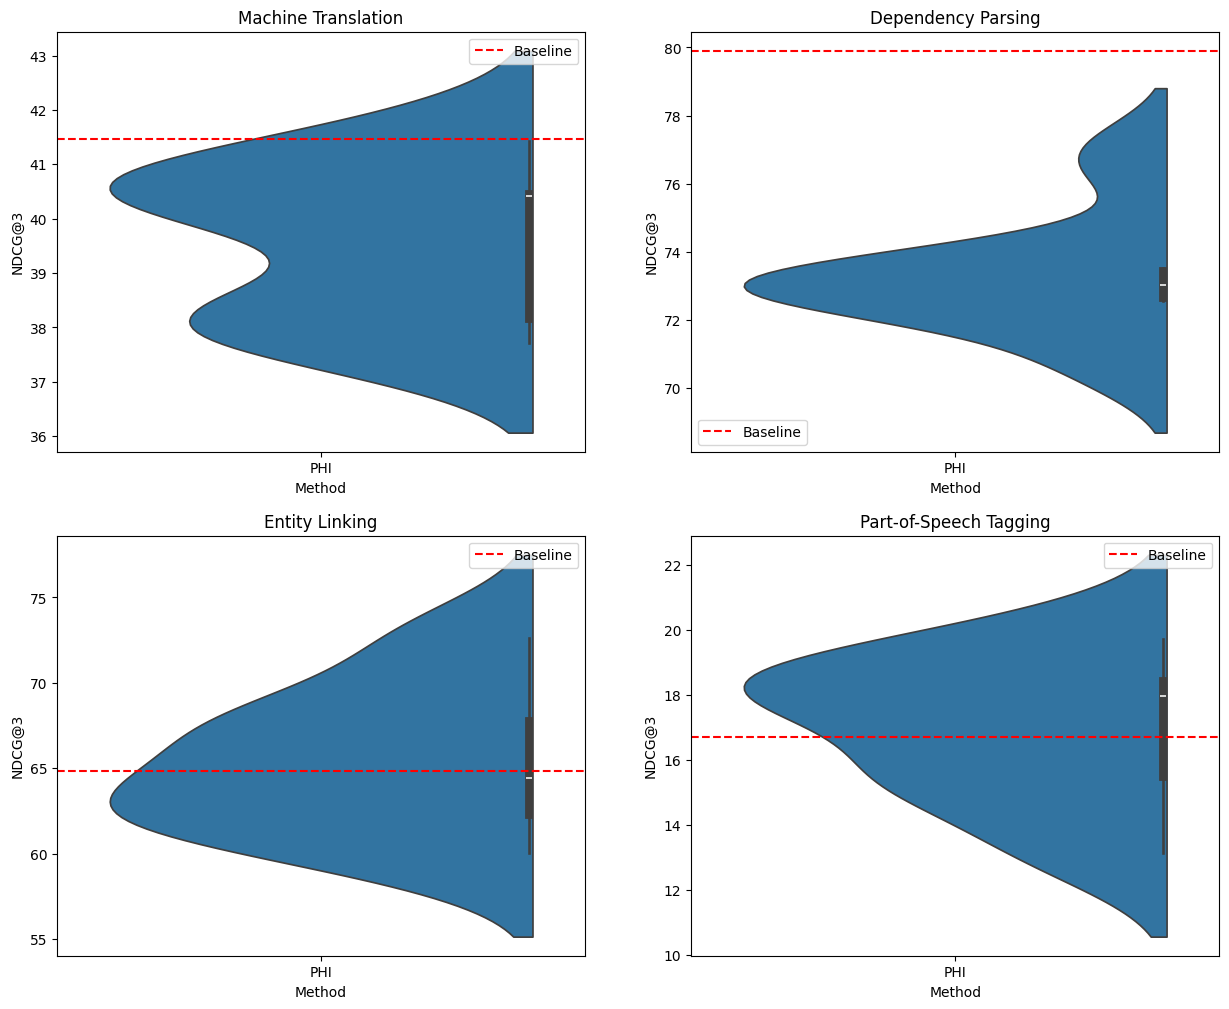

In [2]:
# Read the data
# mi_data = pd.read_csv('results/mi_results.csv')
# phi_data = pd.read_csv('results/phi_results.csv')
phi_data = pd.read_csv('eval_result/imputed_ant_phi_results.csv')
baseline_data = pd.read_csv('eval_result/baseline_results.csv')

# Create a figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.ravel()

# Metrics to plot (excluding num_features column)
metrics = ['mt', 'dep', 'el', 'pos']
names = ["Machine Translation", "Dependency Parsing", "Entity Linking", "Part-of-Speech Tagging"]

# Create violin plots for each metric
for idx, metric in enumerate(metrics):
    # Prepare data for plotting
    plot_data = pd.DataFrame({
        'Method': ['PHI'] * len(phi_data) + ['PHI'] * len(phi_data),
        'Value': pd.concat([phi_data[metric], phi_data[metric]]),
    })
    
    # Create violin plot
    sns.violinplot(data=plot_data, x='Method', y='Value', hue='Method', ax=axes[idx], split=True)
    axes[idx].set_title(f'{names[idx]}')
    axes[idx].set_ylabel('Value')

    # Add horizontal line for baseline
    baseline_value = baseline_data[metric].iloc[0]
    axes[idx].axhline(y=baseline_value, color='red', linestyle='--', label='Baseline')
    
    axes[idx].set_title(f'{names[idx]}')
    axes[idx].set_ylabel('NDCG@3')
    axes[idx].legend()
    
# Adjust layout
plt.show()

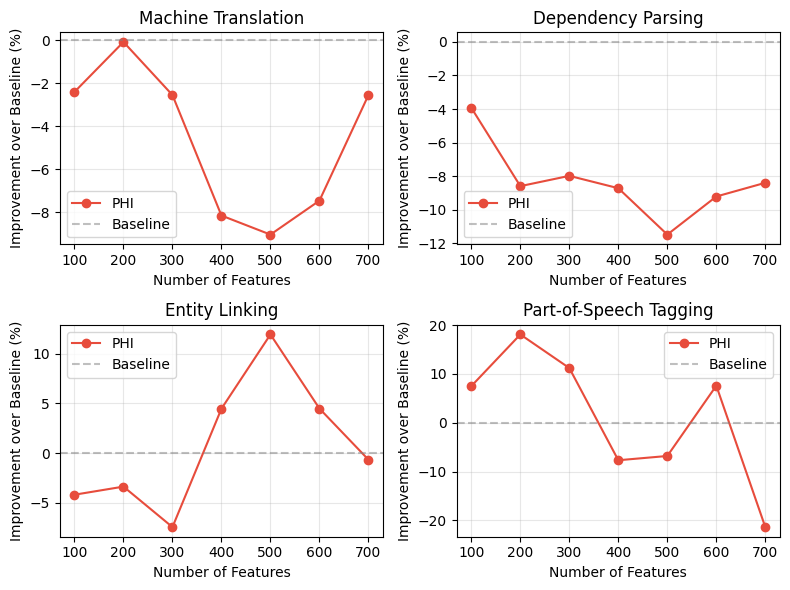

In [3]:
# Plot average improvement over baseline for each task separately

plt.figure(figsize=(8, 6))
for i, metric in enumerate(metrics):
    baseline_value = baseline_data[metric].iloc[0]
    phi_improvement = (phi_data[metric] - baseline_value) / baseline_value * 100

    plt.subplot(2, 2, i + 1)
    plt.plot(phi_data['num_features'], phi_improvement, marker='o', color='#e74c3c', label='PHI')
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Baseline')
    plt.title(f'{names[i]}')
    plt.xlabel('Number of Features')
    plt.ylabel('Improvement over Baseline (%)')
    plt.grid(True, alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()


c:\Users\Chi\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Chi\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
c:\Users\Chi\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
c:\Users\Chi\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
c:\Users\Chi\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


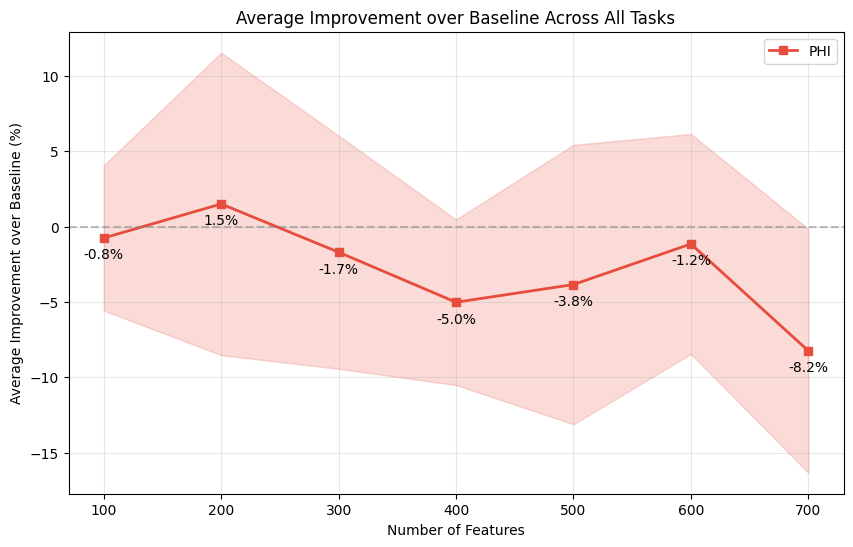

In [4]:
# Calculate average improvements
mi_improvements = []
phi_improvements = []
metrics = ['mt', 'dep', 'el', 'pos']
for metric in metrics:
    baseline_value = baseline_data[metric].iloc[0]
    
    # Calculate percentage improvements for this metric
    # mi_improvement = [(val - baseline_value) / baseline_value * 100 for val in mi_data[metric]]
    phi_improvement = [(val - baseline_value) / baseline_value * 100 for val in phi_data[metric]]
    
    # mi_improvements.append(mi_improvement)
    phi_improvements.append(phi_improvement)

# Convert to numpy arrays and calculate mean and std
mi_improvements = np.array(mi_improvements)
phi_improvements = np.array(phi_improvements)

mi_mean = np.mean(mi_improvements, axis=0)
phi_mean = np.mean(phi_improvements, axis=0)

mi_std = np.std(mi_improvements, axis=0)
phi_std = np.std(phi_improvements, axis=0)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot lines with error bands
# plt.plot(mi_data['num_features'], mi_mean, marker='o', color='#2ecc71', 
#          label='MI', linewidth=2)
# plt.fill_between(mi_data['num_features'], 
#                  mi_mean - mi_std, mi_mean + mi_std,
#                  color='#2ecc71', alpha=0.2)

plt.plot(phi_data['num_features'], phi_mean, marker='s', color='#e74c3c', 
         label='PHI', linewidth=2)
plt.fill_between(phi_data['num_features'], 
                 phi_mean - phi_std, phi_mean + phi_std,
                 color='#e74c3c', alpha=0.2)

# Add horizontal line at 0% (baseline)
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Customize plot
plt.title('Average Improvement over Baseline Across All Tasks')
plt.xlabel('Number of Features')
plt.ylabel('Average Improvement over Baseline (%)')
plt.grid(True, alpha=0.3)
plt.legend()

# Add value labels on points
# for x, y in zip(mi_data['num_features'], mi_mean):
#     plt.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", 
#                 xytext=(0,10), ha='center', fontsize=10)
for x, y in zip(phi_data['num_features'], phi_mean):
    plt.annotate(f'{y:.1f}%', (x, y), textcoords="offset points", 
                xytext=(0,-15), ha='center', fontsize=10)
plt.show()